In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [19]:
df1 = pd.read_csv(r'/workspaces/PCOS-KA-OS/PCOS_data.csv')

df1.columns = df1.columns.str.strip()


target_cols = ['AMH(ng/mL)', 'II    beta-HCG(mIU/mL)']
for col in target_cols:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

    df1[col] = df1[col].fillna(df1[col].median())

# Step 4: Drop the non-medical columns that cause noise
df1 = df1.drop(columns=['Sl. No', 'Patient File No.'], errors='ignore')

print("Errors solved! Data is now clean and numeric.")

Errors solved! Data is now clean and numeric.


In [20]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 43 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              541 non-null    int64  
 1   Age (yrs)               541 non-null    int64  
 2   Weight (Kg)             541 non-null    float64
 3   Height(Cm)              541 non-null    float64
 4   BMI                     541 non-null    float64
 5   Blood Group             541 non-null    int64  
 6   Pulse rate(bpm)         541 non-null    int64  
 7   RR (breaths/min)        541 non-null    int64  
 8   Hb(g/dl)                541 non-null    float64
 9   Cycle(R/I)              541 non-null    int64  
 10  Cycle length(days)      541 non-null    int64  
 11  Marraige Status (Yrs)   540 non-null    float64
 12  Pregnant(Y/N)           541 non-null    int64  
 13  No. of abortions        541 non-null    int64  
 14  I   beta-HCG(mIU/mL)    541 non-null    float64
 15  

In [21]:
df1.describe()

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,540.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,0.327172,31.430684,59.637153,156.484835,24.307579,13.802218,73.247689,19.243993,11.160037,2.560074,...,0.489834,0.514815,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,0.469615,5.411006,11.028287,6.033545,4.055129,1.840812,4.430285,1.688629,0.866904,0.901950,...,0.500359,0.500244,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,0.000000,20.000000,31.000000,137.000000,12.400000,11.000000,13.000000,16.000000,8.500000,2.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,28.000000,52.000000,152.000000,21.600000,13.000000,72.000000,18.000000,10.500000,2.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,0.000000,31.000000,59.000000,156.000000,24.200000,14.000000,72.000000,18.000000,11.000000,2.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,1.000000,35.000000,65.000000,160.000000,26.600000,15.000000,74.000000,20.000000,11.700000,4.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,14.800000,5.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


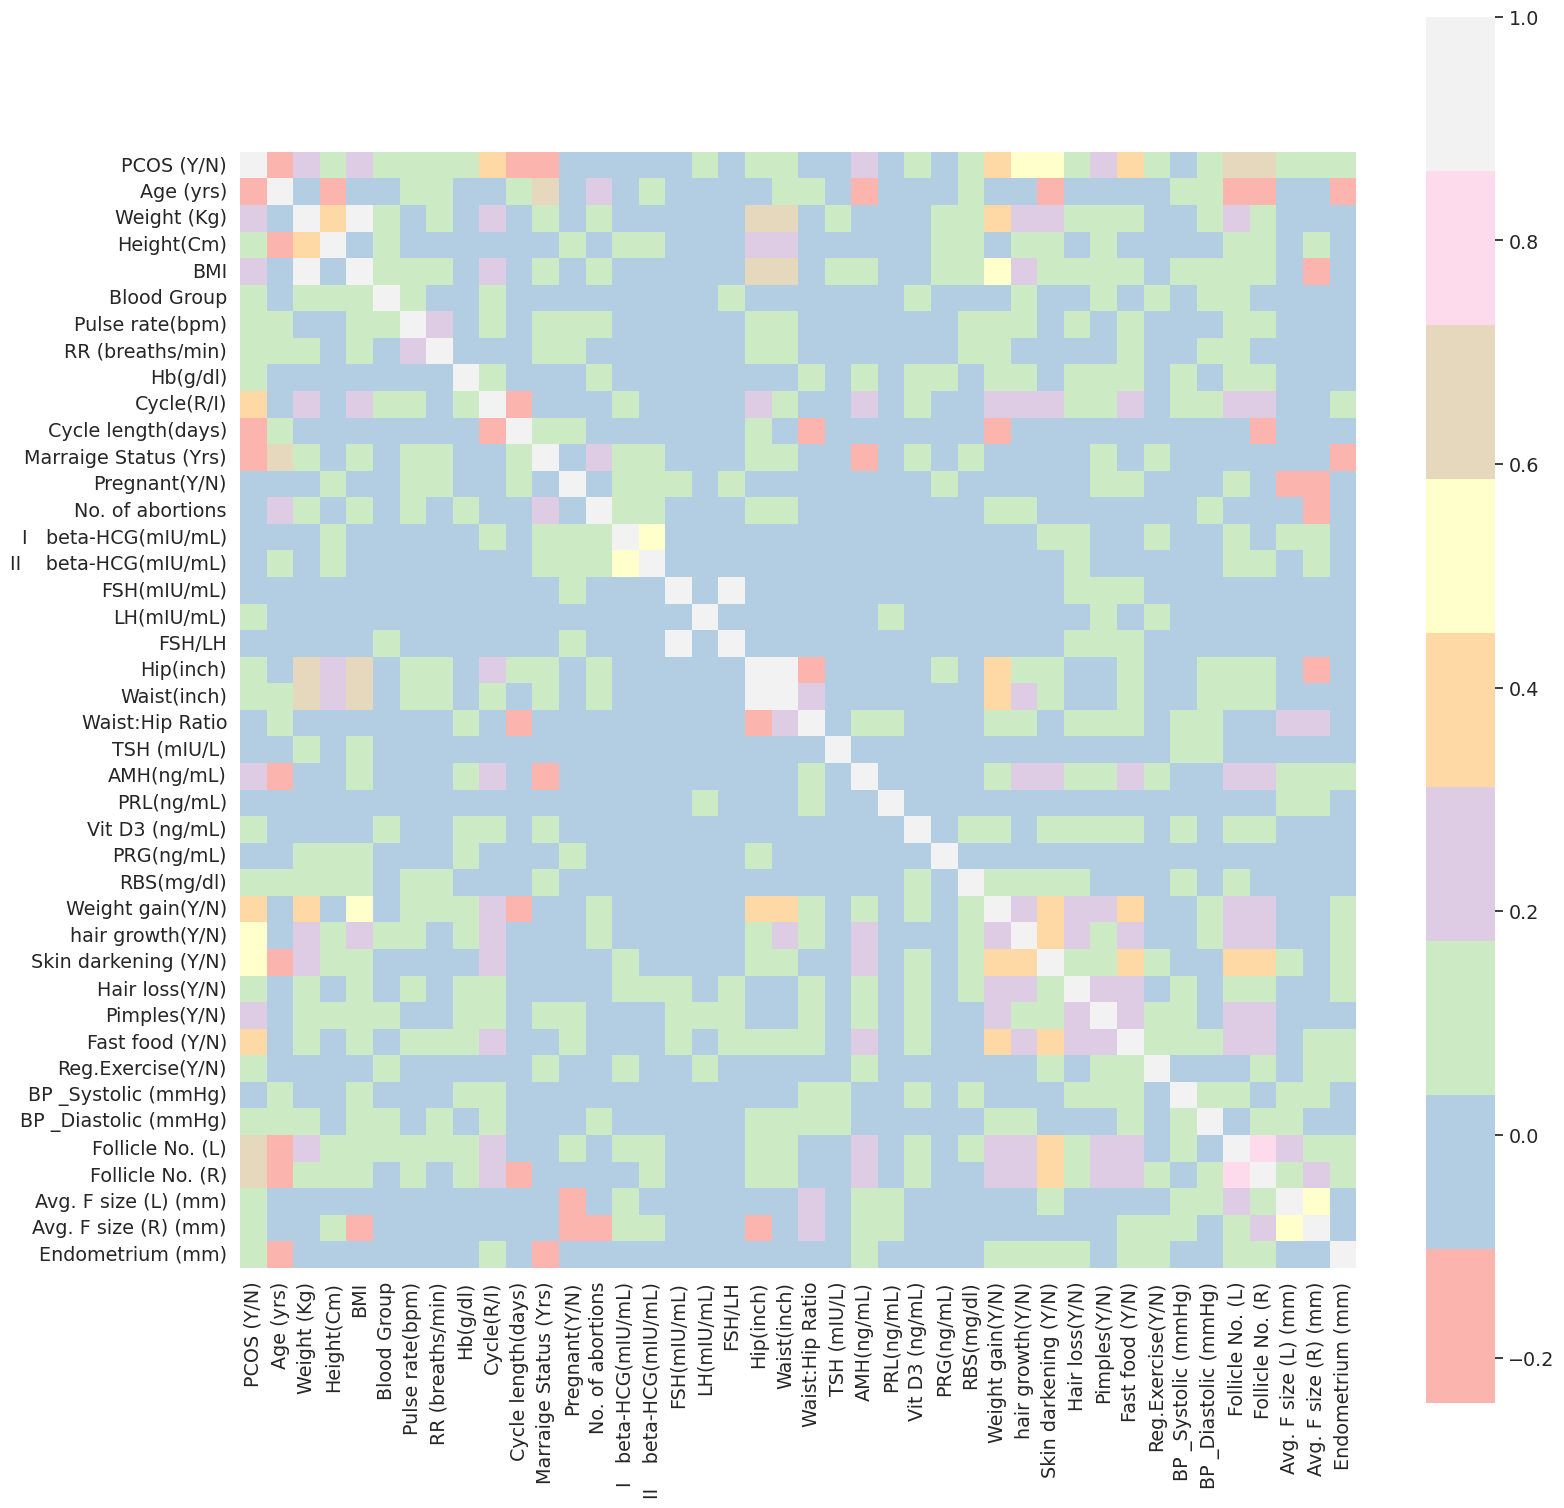

In [22]:
corrmat = df1.corr(numeric_only=True)
plt.subplots(figsize=(18,18))
sns.heatmap(corrmat,cmap="Pastel1", square=True);


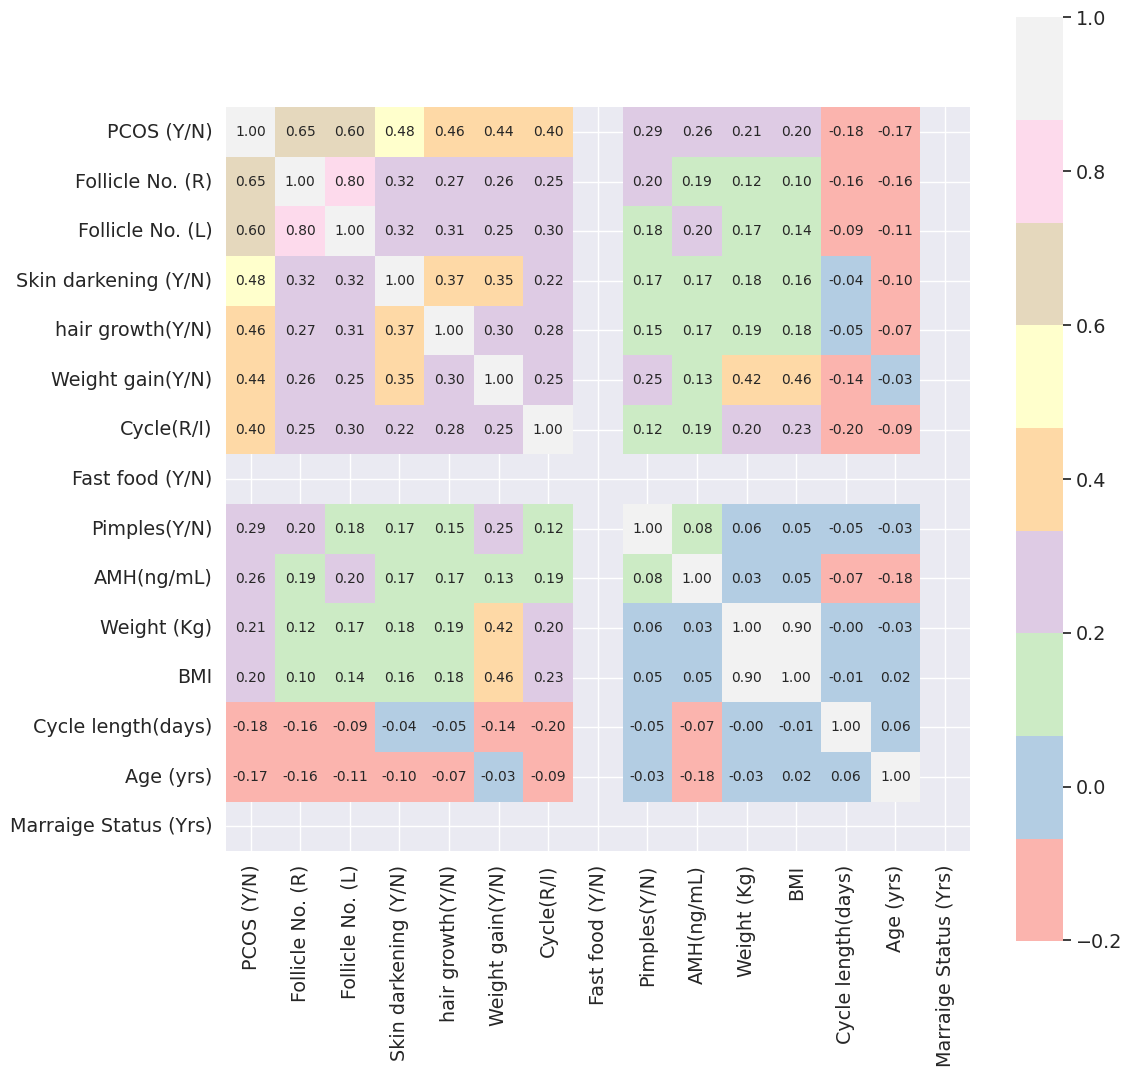

In [23]:
plt.figure(figsize=(12,12))
k = 12 #number of variables with positive for heatmap
l = 3 #number of variables with negative for heatmap
cols_p = corrmat.nlargest(k, "PCOS (Y/N)")["PCOS (Y/N)"].index 
cols_n = corrmat.nsmallest(l, "PCOS (Y/N)")["PCOS (Y/N)"].index
cols = cols_p.append(cols_n) 

cm = np.corrcoef(df1[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True,cmap="Pastel1", annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

feature selection and support vector machine start

In [24]:
from sklearn.svm import SVC
from sklearn.multioutput import ClassifierChain
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [25]:
features = [
    'Follicle No. (L)', 'Follicle No. (R)',
    'AMH(ng/mL)', 'FSH/LH', 'LH(mIU/mL)',
    'Waist:Hip Ratio', 'BMI', 'Cycle length(days)',
    'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)'
]

# Multi-output targets
targets = [
    'PCOS (Y/N)',
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Cycle(R/I)'
]

df1['AMH(ng/mL)'] = pd.to_numeric(df1['AMH(ng/mL)'], errors='coerce')
df1 = df1.dropna(subset=features + targets).copy()

X = df1[features]
y = df1[targets]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42,
    stratify=y['PCOS (Y/N)']
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (432, 10)
y_train shape: (432, 5)


In [26]:
from sklearn.svm import SVC
from sklearn.multioutput import ClassifierChain

svc = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)
chain_model = ClassifierChain(svc, order='random', random_state=42)
chain_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [27]:
y_pred = chain_model.predict(X_test)

labels = ['PCOS (Y/N)', 'Weight gain', 'Hair growth', 'Skin darkening', 'Cycle irregularity']

for i, label in enumerate(labels):
    report = classification_report(
        y_test.iloc[:, i], y_pred[:, i], output_dict=True
    )
    print(f"\n{label}:")
    print(f"  Accuracy:  {accuracy_score(y_test.iloc[:,i], y_pred[:,i])*100:.1f}%")
    print(f"  Precision: {report['weighted avg']['precision']*100:.1f}%")
    print(f"  Recall:    {report['weighted avg']['recall']*100:.1f}%")
    print(f"  F1:        {report['weighted avg']['f1-score']*100:.1f}%")

cm = confusion_matrix(y_test.iloc[:, 0], y_pred[:, 0])
print("\nConfusion matrix (PCOS):\n", cm)


PCOS (Y/N):
  Accuracy:  83.5%
  Precision: 84.1%
  Recall:    83.5%
  F1:        83.7%

Weight gain:
  Accuracy:  68.8%
  Precision: 68.7%
  Recall:    68.8%
  F1:        68.7%

Hair growth:
  Accuracy:  67.0%
  Precision: 67.0%
  Recall:    67.0%
  F1:        67.0%

Skin darkening:
  Accuracy:  66.1%
  Precision: 68.2%
  Recall:    66.1%
  F1:        66.9%

Cycle irregularity:
  Accuracy:  87.2%
  Precision: 86.9%
  Recall:    87.2%
  F1:        87.0%

Confusion matrix (PCOS):
 [[62 11]
 [ 7 29]]


In [28]:
for i, col in enumerate(targets):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))


--- PCOS (Y/N) ---
              precision    recall  f1-score   support

           0       0.90      0.85      0.87        73
           1       0.72      0.81      0.76        36

    accuracy                           0.83       109
   macro avg       0.81      0.83      0.82       109
weighted avg       0.84      0.83      0.84       109


--- Weight gain(Y/N) ---
              precision    recall  f1-score   support

           0       0.71      0.73      0.72        60
           1       0.66      0.63      0.65        49

    accuracy                           0.69       109
   macro avg       0.68      0.68      0.68       109
weighted avg       0.69      0.69      0.69       109


--- hair growth(Y/N) ---
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        77
           1       0.44      0.44      0.44        32

    accuracy                           0.67       109
   macro avg       0.60      0.60      0.60       109
we

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier , ClassifierChain
rf = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Compare on primary target only
print("SVM PCOS Accuracy:", accuracy_score(y_test['PCOS (Y/N)'], y_pred[:, 0]))
print("RF  PCOS Accuracy:", accuracy_score(y_test['PCOS (Y/N)'], rf_pred[:, 0]))

SVM PCOS Accuracy: 0.8348623853211009
RF  PCOS Accuracy: 0.8532110091743119


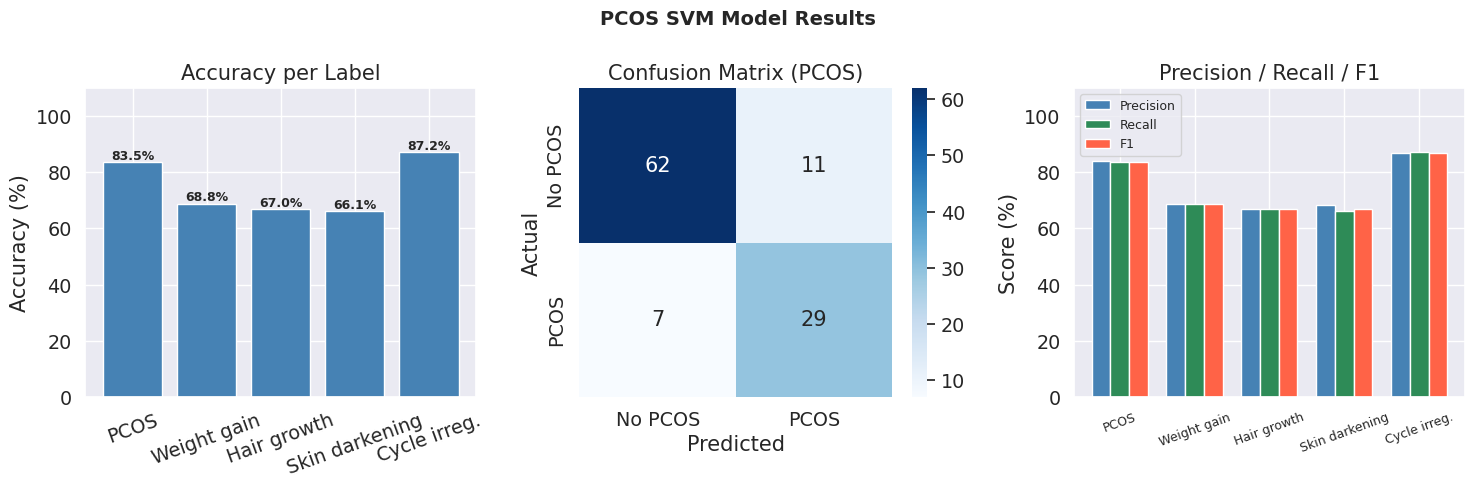

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

label_names = ['PCOS', 'Weight gain', 'Hair growth', 'Skin darkening', 'Cycle irreg.']

# collect accuracy per label
accs = [accuracy_score(y_test.iloc[:, i], y_pred[:, i]) * 100
        for i in range(len(label_names))]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('PCOS SVM Model Results', fontsize=14, fontweight='bold')

# ── 1. Accuracy bar chart ──────────────────────────
axes[0].bar(label_names, accs, color='steelblue', edgecolor='white')
axes[0].set_ylim(0, 110)
axes[0].set_title('Accuracy per Label')
axes[0].set_ylabel('Accuracy (%)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(accs):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── 2. Confusion matrix (PCOS label) ──────────────
cm = confusion_matrix(y_test.iloc[:, 0], y_pred[:, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No PCOS', 'PCOS'],
            yticklabels=['No PCOS', 'PCOS'])
axes[1].set_title('Confusion Matrix (PCOS)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# ── 3. Precision / Recall / F1 grouped bar ────────
metrics = {'Precision': [], 'Recall': [], 'F1': []}
for i in range(len(label_names)):
    rep = classification_report(y_test.iloc[:, i], y_pred[:, i],
                                 output_dict=True, zero_division=0)
    metrics['Precision'].append(rep['weighted avg']['precision'] * 100)
    metrics['Recall'].append(rep['weighted avg']['recall'] * 100)
    metrics['F1'].append(rep['weighted avg']['f1-score'] * 100)

x = np.arange(len(label_names))
w = 0.25
axes[2].bar(x - w, metrics['Precision'], width=w, label='Precision', color='steelblue')
axes[2].bar(x,     metrics['Recall'],    width=w, label='Recall',    color='seagreen')
axes[2].bar(x + w, metrics['F1'],        width=w, label='F1',        color='tomato')
axes[2].set_xticks(x)
axes[2].set_xticklabels(label_names, rotation=20, fontsize=9)
axes[2].set_ylim(0, 110)
axes[2].set_title('Precision / Recall / F1')
axes[2].set_ylabel('Score (%)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [35]:
import pickle
pickle.dump(chain_model, open('pcos_chain_svm.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
print("Saved!")

Saved!
